In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

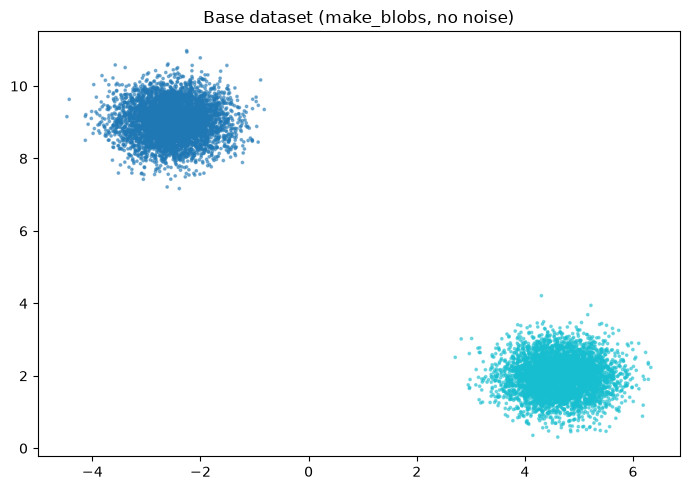

In [38]:
# GENERATE BASE DATASET MAKE BLOBS
np.random.seed(1)
N_BASE = 10000
N_CLUSTERS = 2

X_base, y_base = make_blobs(n_samples=N_BASE, centers=N_CLUSTERS, cluster_std=0.5, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X_base[:, 0], X_base[:, 1], c=y_base, cmap='tab10', s=3, alpha=0.5)
plt.title("Base dataset (make_blobs, no noise)")
plt.tight_layout()
plt.show()

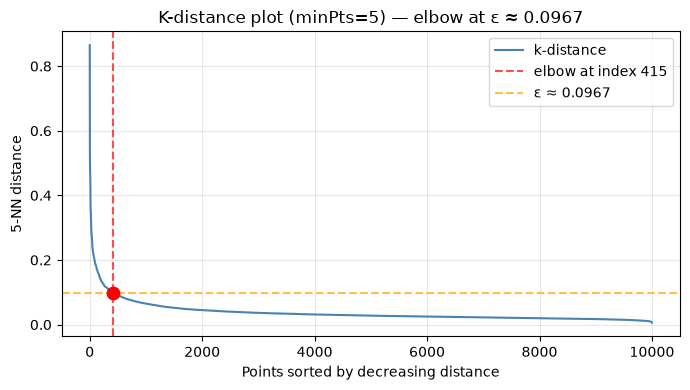

Elbow at index 415, ε ≈ 0.0967
Experiment parameters: ε=0.09672987247603253, minPts=5


In [34]:
def plot_k_distance(X, min_pts):
    nbrs = NearestNeighbors(n_neighbors=min_pts).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_distances = np.sort(distances[:, -1])[::-1]

    # Find elbow programmatically
    x = np.arange(len(k_distances))
    x_norm = x / x.max()
    y_norm = k_distances / k_distances.max()
    distances_to_line = np.abs(y_norm - (1 - x_norm))
    elbow_idx = np.argmax(distances_to_line)
    elbow_eps = k_distances[elbow_idx]

    plt.figure(figsize=(7, 4))
    plt.plot(k_distances, color='steelblue', label='k-distance')
    plt.axvline(x=elbow_idx, color='red', linestyle='--', alpha=0.7, label=f'elbow at index {elbow_idx}')
    plt.axhline(y=elbow_eps, color='orange', linestyle='--', alpha=0.7, label=f'ε ≈ {elbow_eps:.4f}')
    plt.scatter([elbow_idx], [elbow_eps], color='red', zorder=5, s=80)
    plt.xlabel("Points sorted by decreasing distance")
    plt.ylabel(f"{min_pts}-NN distance")
    plt.title(f"K-distance plot (minPts={min_pts}) — elbow at ε ≈ {elbow_eps:.4f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Elbow at index {elbow_idx}, ε ≈ {elbow_eps:.4f}")
    return elbow_eps

MIN_PTS = 5
EPSILON = plot_k_distance(X_base, MIN_PTS)
print(f"Experiment parameters: ε={EPSILON}, minPts={MIN_PTS}")

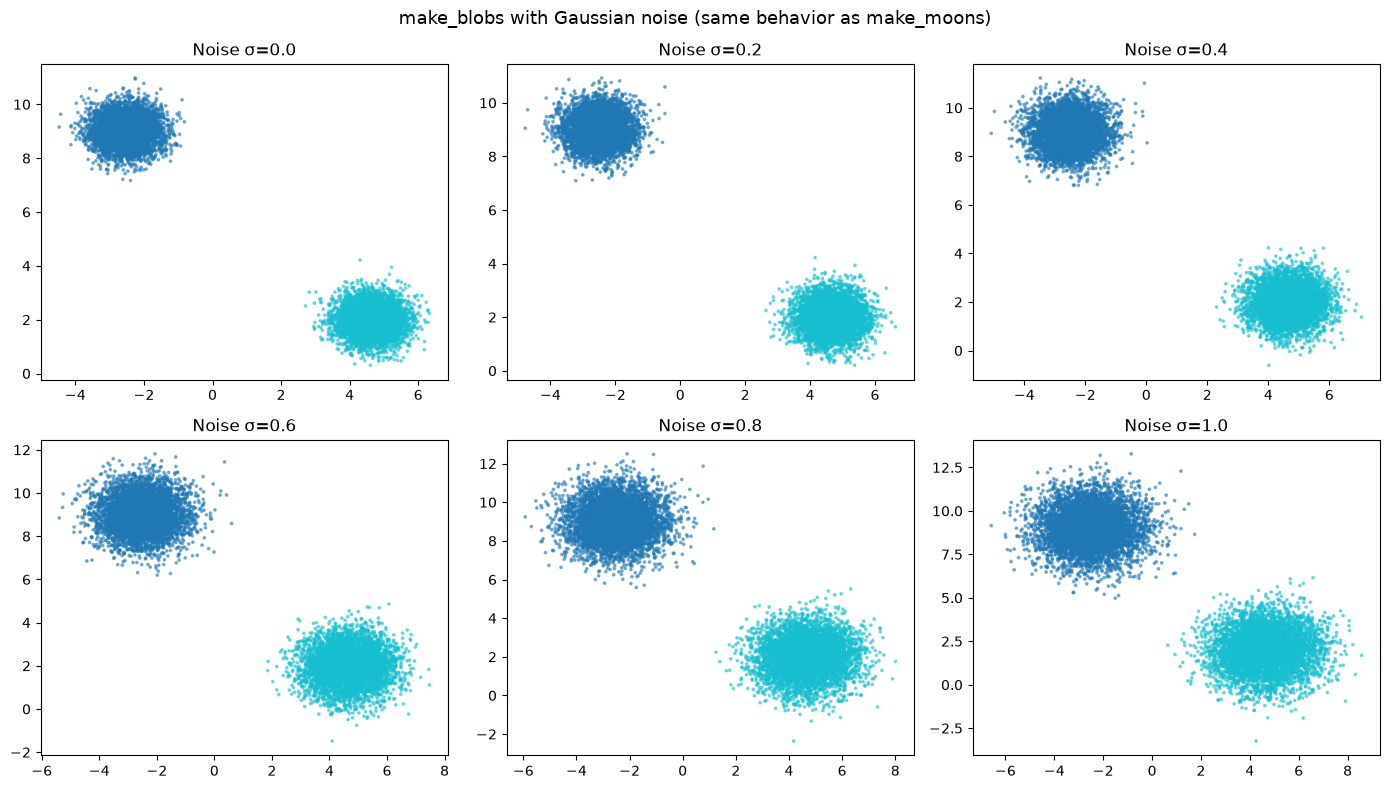

In [35]:
NOISE_LEVELS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
# NOISE_LEVELS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25]

def add_noise(X, noise_std, random_state=None):
    rng = np.random.default_rng(random_state)

    return X + rng.normal(
        loc=0,
        scale=noise_std,
        size=X.shape
    )

NOISE_LEVELS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, noise_std in enumerate(NOISE_LEVELS):

    X_noisy = add_noise(
        X_base,
        noise_std=noise_std,
        random_state=42
    )

    axes[i].scatter(
        X_noisy[:, 0],
        X_noisy[:, 1],
        c=y_base,
        cmap='tab10',
        s=3,
        alpha=0.5
    )

    axes[i].set_title(f"Noise σ={noise_std}")

plt.suptitle(
    "make_blobs with Gaussian noise (same behavior as make_moons)",
    fontsize=13
)
plt.tight_layout()
plt.show()

In [36]:
import os
import numpy as np
from sklearn.datasets import make_blobs

# -----------------------------
# CONFIG
# -----------------------------
INPUT_DIR = "input"
os.makedirs(INPUT_DIR, exist_ok=True)

NOISE_LEVELS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

n = 10000
d = 2
k = 2
cluster_std = 0.5
R = 1

# IMPORTANT: must match parser expectation
epsilon = 0.0967
min_pts = 4

# -----------------------------
# NOISE FUNCTION
# -----------------------------
def add_noise(X, noise_std, rng):
    return X + rng.normal(
        loc=0,
        scale=noise_std,
        size=X.shape
    )

# -----------------------------
# GENERATION
# -----------------------------
files_written = 0

for noise_std in NOISE_LEVELS:
    for r in range(1, R + 1):

        rng = np.random.default_rng(r)

        # generate blobs
        X, _ = make_blobs(
            n_samples=n,
            n_features=d,
            centers=k,
            cluster_std=cluster_std,
            random_state=r
        )

        # add noise
        X_noisy = add_noise(X, noise_std, rng)

        # filename
        fname = os.path.join(INPUT_DIR, f"blobs_{noise_std:.1f}.in")

        with open(fname, "w") as f:
            # ✅ FORMAT REQUIRED BY YOUR PARSER
            f.write(f"{n} {d} {epsilon} {min_pts}\n")

            for point in X_noisy:
                f.write(" ".join(str(float(coord)) for coord in point) + "\n")

        files_written += 1

    print(f"noise={noise_std}: {R} file(s) written -> blobs_{noise_std:.1f}.in")

print(f"\nDone — {files_written} dataset files saved to '{INPUT_DIR}/'")

noise=0.0: 1 file(s) written -> blobs_0.0.in
noise=0.2: 1 file(s) written -> blobs_0.2.in
noise=0.4: 1 file(s) written -> blobs_0.4.in
noise=0.6: 1 file(s) written -> blobs_0.6.in
noise=0.8: 1 file(s) written -> blobs_0.8.in
noise=1.0: 1 file(s) written -> blobs_1.0.in

Done — 6 dataset files saved to 'input/'


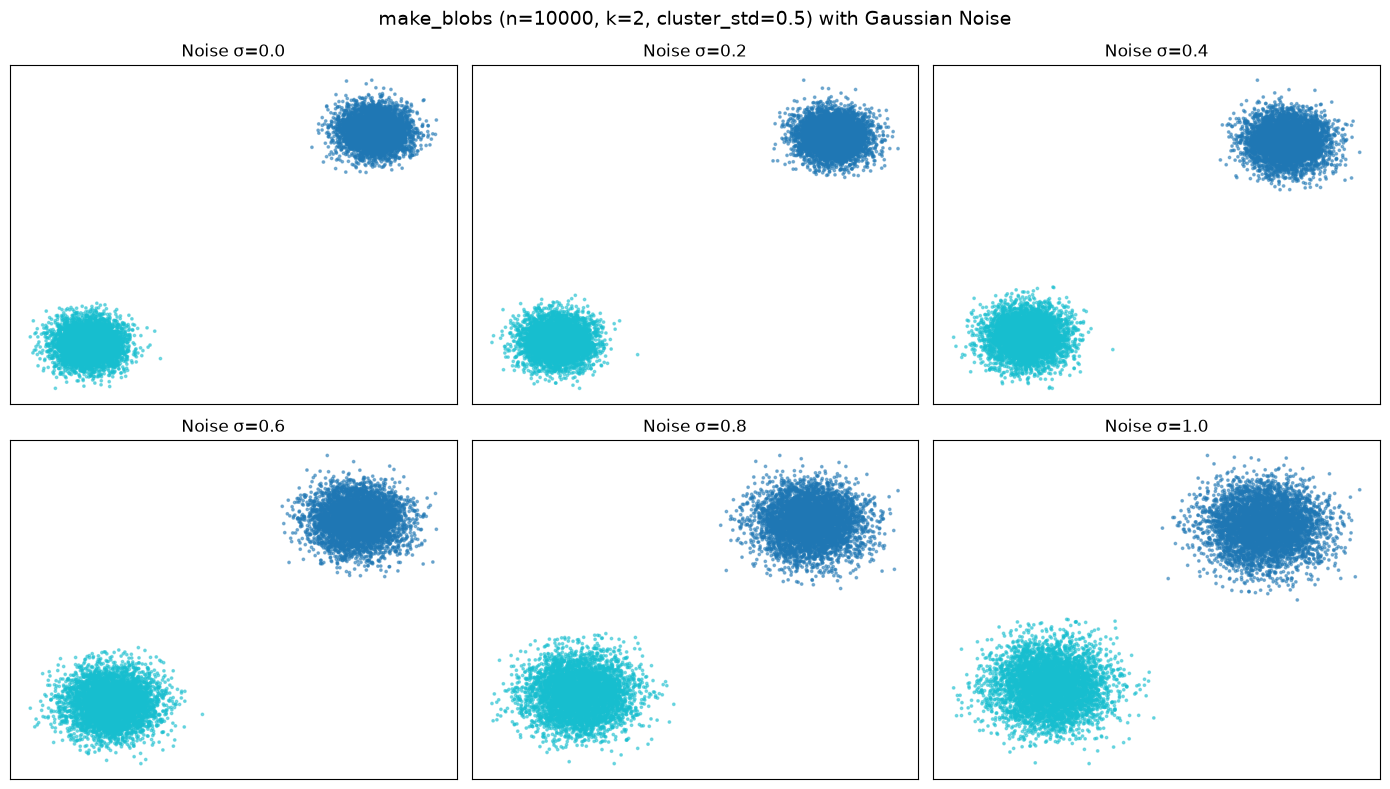

In [37]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, noise_std in enumerate(NOISE_LEVELS):

    rng = np.random.default_rng(1)

    # Generate the same dataset used for writing
    X, y = make_blobs(
        n_samples=n,
        n_features=d,
        centers=k,
        cluster_std=cluster_std,
        random_state=1
    )

    X_noisy = add_noise(X, noise_std, rng)

    axes[i].scatter(
        X_noisy[:, 0],
        X_noisy[:, 1],
        c=y,
        cmap="tab10",
        s=3,
        alpha=0.5
    )

    axes[i].set_title(f"Noise σ={noise_std}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.suptitle(
    f"make_blobs (n={n}, k={k}, cluster_std={cluster_std}) with Gaussian Noise",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

In [42]:
# Dataset parameters
N = 1000
D = 2
K = 2
CLUSTER_STD = 0.5

# DBSCAN parameters
MIN_PTS = 5

# Noise experiment
NOISE_LEVELS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Output
INPUT_DIR = "input"
os.makedirs(INPUT_DIR, exist_ok=True)

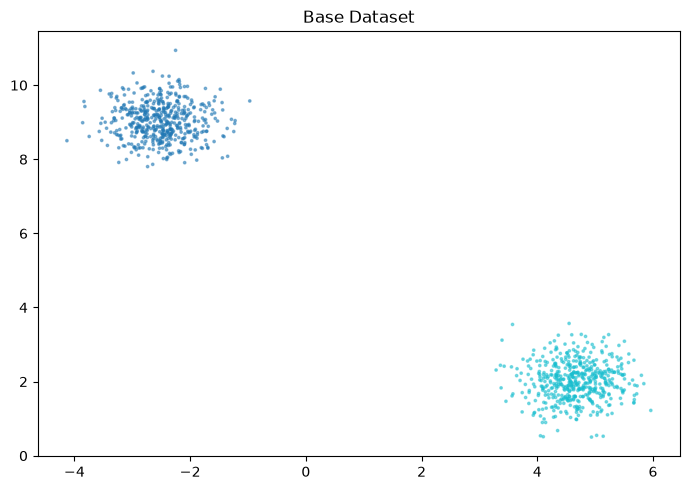

In [43]:
X_base, y_base = make_blobs(
    n_samples=N,
    centers=K,
    cluster_std=CLUSTER_STD,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_base[:, 0],
    X_base[:, 1],
    c=y_base,
    cmap="tab10",
    s=3,
    alpha=0.5
)

plt.title("Base Dataset")
plt.tight_layout()
plt.show()

In [44]:
def estimate_epsilon(X, min_pts):
    nbrs = NearestNeighbors(n_neighbors=min_pts).fit(X)

    distances, _ = nbrs.kneighbors(X)

    k_distances = np.sort(distances[:, -1])[::-1]

    x = np.arange(len(k_distances))
    x_norm = x / x.max()
    y_norm = k_distances / k_distances.max()

    distances_to_line = np.abs(y_norm - (1 - x_norm))

    elbow_idx = np.argmax(distances_to_line)
    epsilon = k_distances[elbow_idx]

    plt.figure(figsize=(7, 4))
    plt.plot(k_distances)

    plt.axvline(elbow_idx, linestyle="--")
    plt.axhline(epsilon, linestyle="--")

    plt.scatter(
        elbow_idx,
        epsilon,
        s=80
    )

    plt.xlabel("Points sorted by decreasing distance")
    plt.ylabel(f"{min_pts}-NN distance")
    plt.title(f"Estimated ε ≈ {epsilon:.4f}")

    plt.grid(alpha=0.3)
    plt.show()

    return epsilon

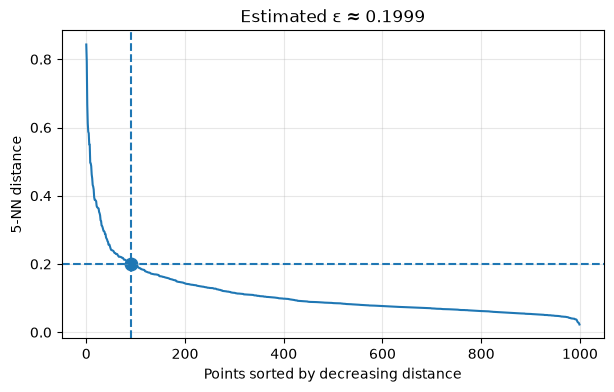

ε = 0.1999
minPts = 5


In [45]:
EPSILON = estimate_epsilon(X_base, MIN_PTS)

print(f"ε = {EPSILON:.4f}")
print(f"minPts = {MIN_PTS}")

In [46]:
def add_noise(X, noise_std, seed=42):
    rng = np.random.default_rng(seed)

    return X + rng.normal(
        loc=0,
        scale=noise_std,
        size=X.shape
    )

In [49]:
for noise_std in NOISE_LEVELS:

    X_noisy = add_noise(
        X_base,
        noise_std,
        seed=42
    )

    filename = os.path.join(
        INPUT_DIR,
        f"blobs_{noise_std:.1f}.in"
    )

    with open(filename, "w") as f:

        f.write(
            f"{N} {D} {EPSILON:.4f} {MIN_PTS}\n"
        )

        for point in X_noisy:
            f.write(
                " ".join(map(str, point))
                + "\n"
            )

    print(f"Saved {filename}")

Saved input\blobs_0.0.in
Saved input\blobs_0.2.in
Saved input\blobs_0.4.in
Saved input\blobs_0.6.in
Saved input\blobs_0.8.in
Saved input\blobs_1.0.in


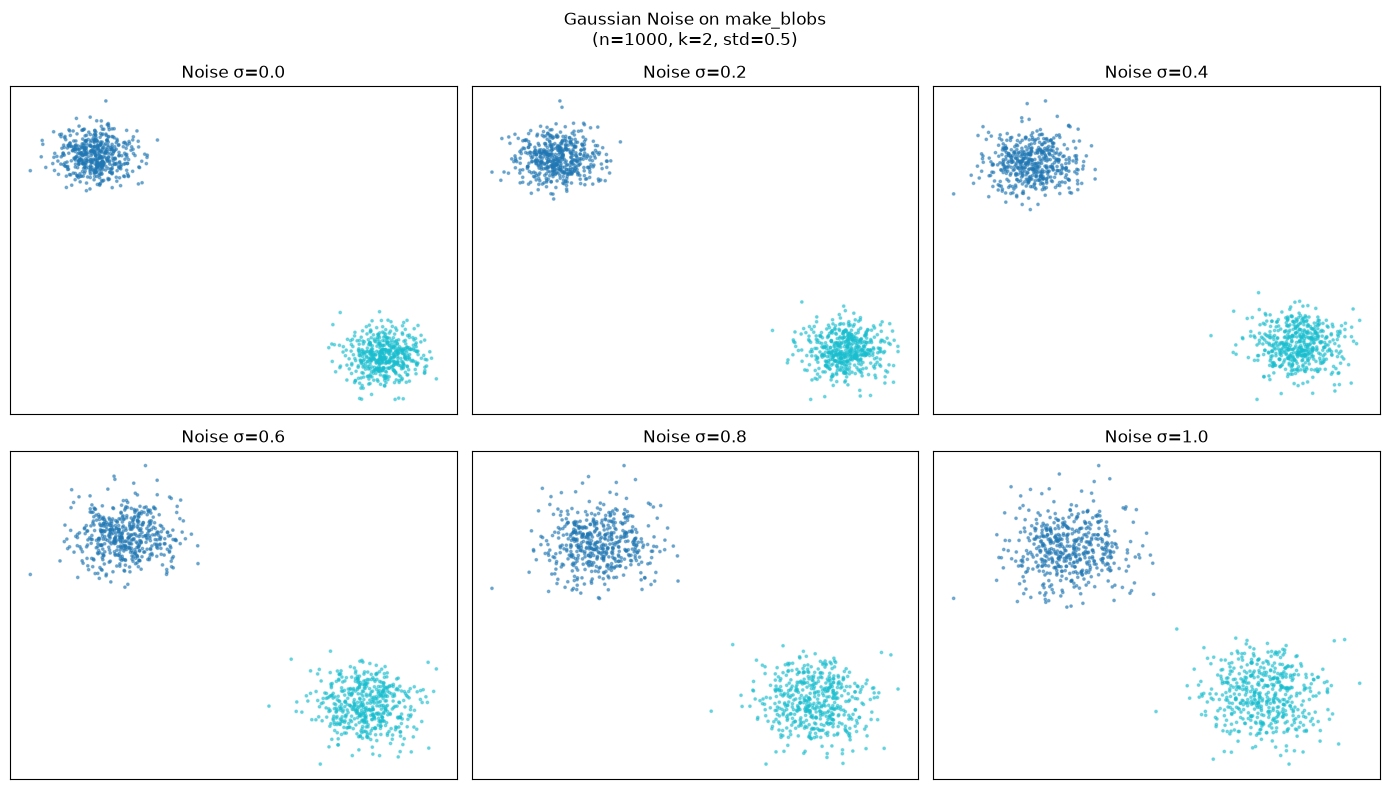

In [50]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8)
)

axes = axes.flatten()

for ax, noise_std in zip(axes, NOISE_LEVELS):

    X_noisy = add_noise(
        X_base,
        noise_std,
        seed=1
    )

    ax.scatter(
        X_noisy[:, 0],
        X_noisy[:, 1],
        c=y_base,
        cmap="tab10",
        s=3,
        alpha=0.5
    )

    ax.set_title(f"Noise σ={noise_std}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    f"Gaussian Noise on make_blobs\n"
    f"(n={N}, k={K}, std={CLUSTER_STD})"
)

plt.tight_layout()
plt.show()